In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sum())

Shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
0


Transaction counts:
Normal (0): 284315
Fraud  (1): 492

Percentages:
Normal: 99.8273%
Fraud:  0.1727%


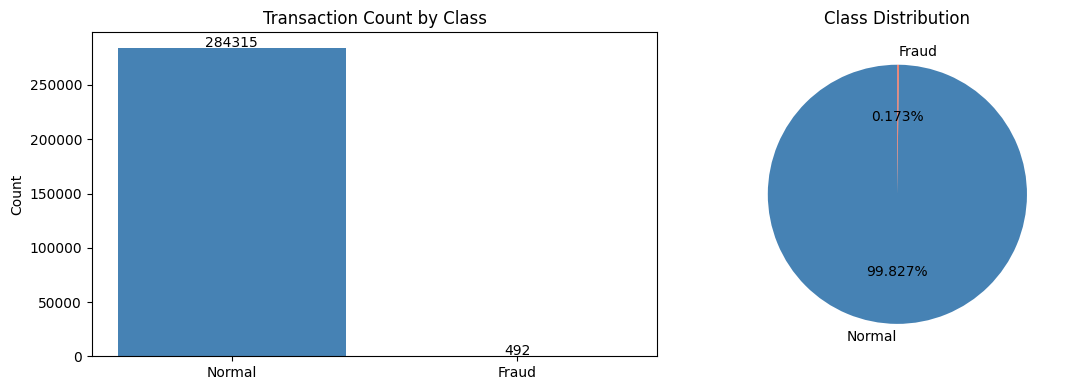

In [2]:
# Count fraud vs normal transactions
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Transaction counts:")
print(f"Normal (0): {class_counts[0]}")
print(f"Fraud  (1): {class_counts[1]}")

print("\nPercentages:")
print(f"Normal: {class_percentages[0].round(4)}%")
print(f"Fraud:  {class_percentages[1].round(4)}%")

# Visualise the imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Normal", "Fraud"],
            [class_counts[0], class_counts[1]],
            color=["steelblue", "tomato"])
axes[0].set_title("Transaction Count by Class")
axes[0].set_ylabel("Count")

# Add counts on top of bars
axes[0].text(0, class_counts[0] + 1000,
             str(class_counts[0]), ha="center")
axes[0].text(1, class_counts[1] + 1000,
             str(class_counts[1]), ha="center")

# Pie chart to show proportion visually
axes[1].pie([class_counts[0], class_counts[1]],
            labels=["Normal", "Fraud"],
            colors=["steelblue", "tomato"],
            autopct="%1.3f%%",
            startangle=90)
axes[1].set_title("Class Distribution")

plt.tight_layout()
plt.show()

Amount statistics -- Normal transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Amount statistics -- Fraud transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


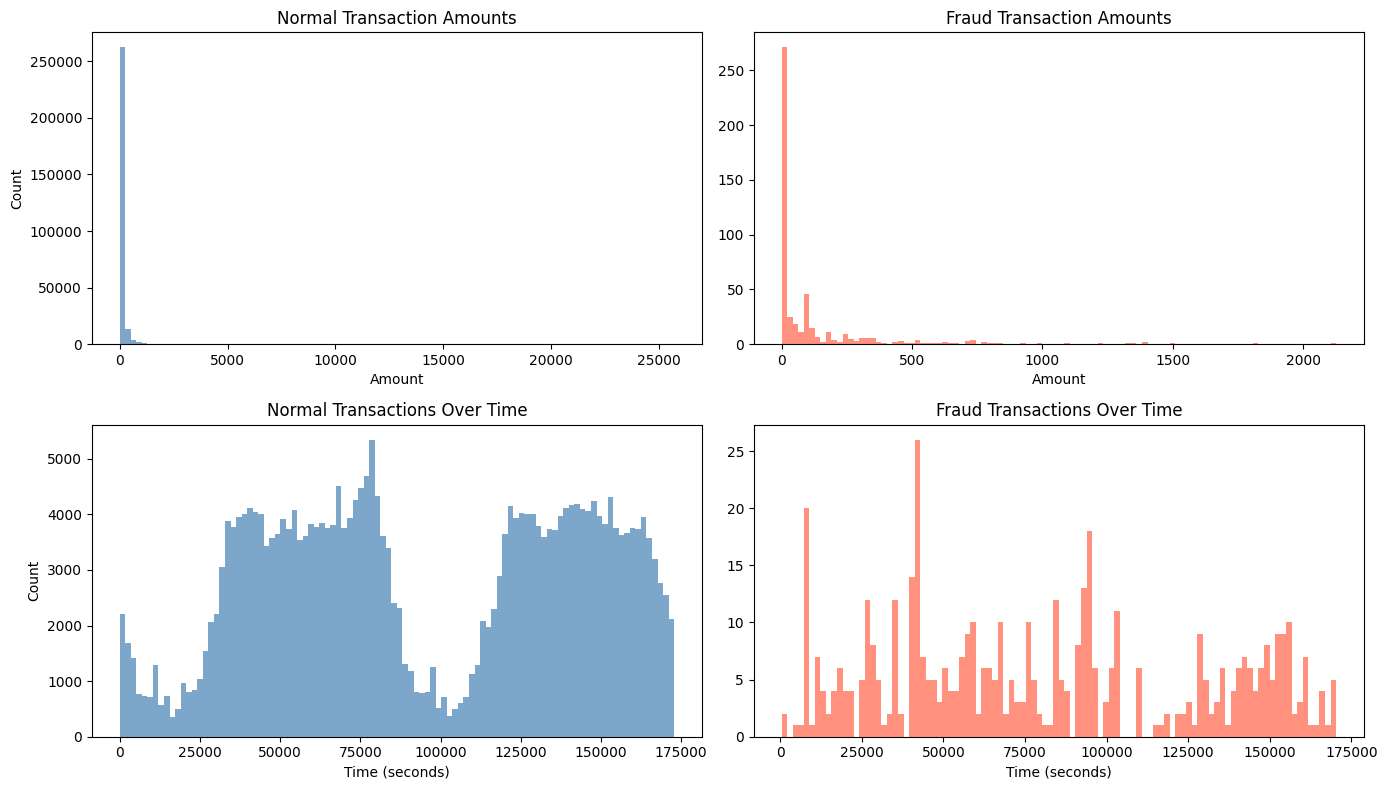

In [3]:
# Separate fraud and normal for comparison
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Amount statistics -- Normal transactions:")
print(normal["Amount"].describe().round(2))

print("\nAmount statistics -- Fraud transactions:")
print(fraud["Amount"].describe().round(2))

# Visualise amount distribution for both classes
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Normal transaction amounts
axes[0, 0].hist(normal["Amount"], bins=100,
                color="steelblue", alpha=0.7)
axes[0, 0].set_title("Normal Transaction Amounts")
axes[0, 0].set_xlabel("Amount")
axes[0, 0].set_ylabel("Count")

# Fraud transaction amounts
axes[0, 1].hist(fraud["Amount"], bins=100,
                color="tomato", alpha=0.7)
axes[0, 1].set_title("Fraud Transaction Amounts")
axes[0, 1].set_xlabel("Amount")

# Time distribution -- normal
axes[1, 0].hist(normal["Time"], bins=100,
                color="steelblue", alpha=0.7)
axes[1, 0].set_title("Normal Transactions Over Time")
axes[1, 0].set_xlabel("Time (seconds)")
axes[1, 0].set_ylabel("Count")

# Time distribution -- fraud
axes[1, 1].hist(fraud["Time"], bins=100,
                color="tomato", alpha=0.7)
axes[1, 1].set_title("Fraud Transactions Over Time")
axes[1, 1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale only Amount and Time -- V1 to V28 are already scaled
# We create a copy to avoid modifying the original dataframe
X = X.copy()
scaler = StandardScaler()
X[["Amount", "Time"]] = scaler.fit_transform(X[["Amount", "Time"]])

# Train test split -- stratify ensures both splits have same fraud ratio
# Without stratify, random chance might put all fraud in one split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # this is new -- you have not used this before
)

print("Training set shape:", X_train.shape)
print("Test set shape:    ", X_test.shape)

print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in test set:    ", y_test.sum())

print("\nFraud rate in training set:",
      round(y_train.sum() / len(y_train) * 100, 4), "%")
print("Fraud rate in test set:    ",
      round(y_test.sum() / len(y_test) * 100, 4), "%")

Training set shape: (227845, 30)
Test set shape:     (56962, 30)

Fraud cases in training set: 394
Fraud cases in test set:     98

Fraud rate in training set: 0.1729 %
Fraud rate in test set:     0.172 %


=== Baseline Model (No Imbalance Handling) ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



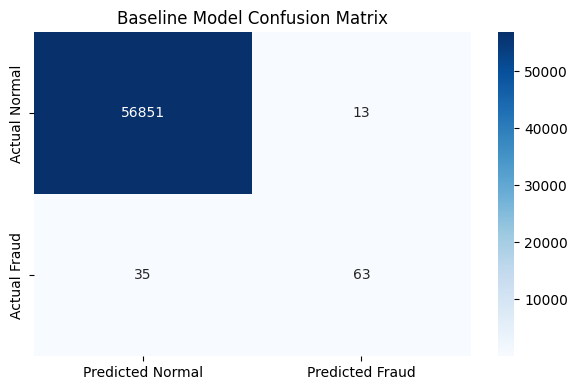

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train logistic regression on raw imbalanced data
# max_iter increased because fraud data needs more iterations to converge
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)

# Predict on test set
y_pred_baseline = lr_baseline.predict(X_test)

# Evaluation
print("=== Baseline Model (No Imbalance Handling) ===\n")
print(classification_report(y_test, y_pred_baseline,
                            target_names=["Normal", "Fraud"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted Fraud"],
            yticklabels=["Actual Normal", "Actual Fraud"])
plt.title("Baseline Model Confusion Matrix")
plt.tight_layout()
plt.show()

In [8]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data -- never on test data
# Applying it to test data would give artificially optimistic results
# This is the same data leakage principle as fitting scaler only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"Normal: {(y_train == 0).sum()}")
print(f"Fraud:  {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"Normal: {(y_train_smote == 0).sum()}")
print(f"Fraud:  {(y_train_smote == 1).sum()}")

print("\nTotal training samples before:", len(y_train))
print("Total training samples after: ", len(y_train_smote))

Before SMOTE:
Normal: 227451
Fraud:  394

After SMOTE:
Normal: 227451
Fraud:  227451

Total training samples before: 227845
Total training samples after:  454902


=== Model After SMOTE ===

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



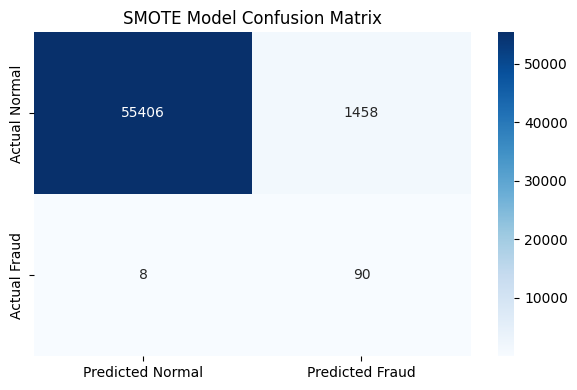


=== Direct Comparison ===
Baseline fraud recall:  0.64
SMOTE fraud recall:     0.92

Baseline fraud missed:  35
SMOTE fraud missed:     8


In [9]:
# Train on SMOTE balanced training data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

# Predict on the original imbalanced test set
# Test set is never touched by SMOTE
y_pred_smote = lr_smote.predict(X_test)

print("=== Model After SMOTE ===\n")
print(classification_report(y_test, y_pred_smote,
                            target_names=["Normal", "Fraud"]))

# Confusion matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Normal", "Predicted Fraud"],
            yticklabels=["Actual Normal", "Actual Fraud"])
plt.title("SMOTE Model Confusion Matrix")
plt.tight_layout()
plt.show()

# Direct comparison
print("\n=== Direct Comparison ===")
print(f"Baseline fraud recall:  {0.64}")
print(f"SMOTE fraud recall:     "
      f"{round(classification_report(y_test, y_pred_smote, output_dict=True)['1']['recall'], 2)}")
print(f"\nBaseline fraud missed:  35")
print(f"SMOTE fraud missed:     {cm_smote[1][0]}")

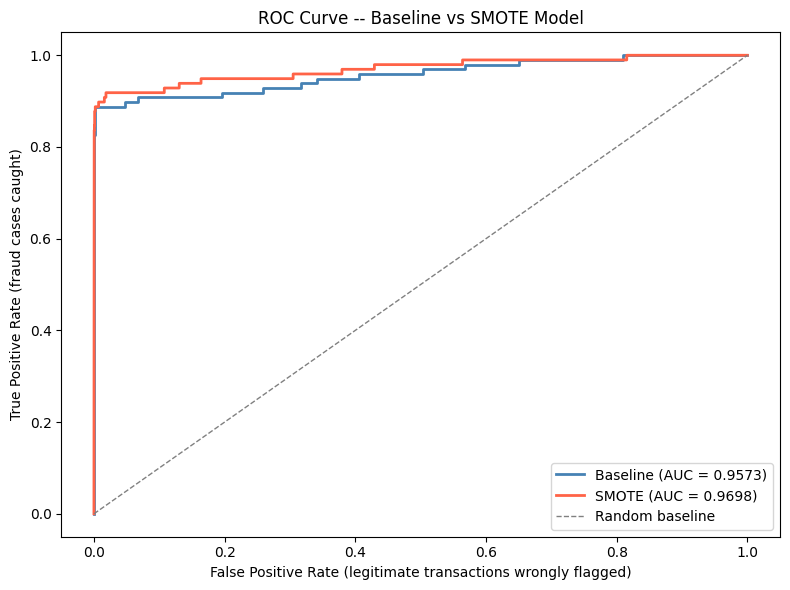

Baseline AUC: 0.9573
SMOTE AUC:    0.9698


In [10]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores instead of hard predictions
# predict_proba returns the probability of each class
# we take column 1 which is the fraud probability
y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

# Compute ROC curves for both models
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_prob_baseline)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

# Compute AUC scores
auc_baseline = roc_auc_score(y_test, y_prob_baseline)
auc_smote = roc_auc_score(y_test, y_prob_smote)

# Plot both curves together
plt.figure(figsize=(8, 6))

plt.plot(fpr_baseline, tpr_baseline,
         color="steelblue", linewidth=2,
         label=f"Baseline (AUC = {auc_baseline:.4f})")

plt.plot(fpr_smote, tpr_smote,
         color="tomato", linewidth=2,
         label=f"SMOTE (AUC = {auc_smote:.4f})")

# Random baseline -- a useless model would sit on this line
plt.plot([0, 1], [0, 1],
         color="gray", linewidth=1,
         linestyle="--", label="Random baseline")

plt.title("ROC Curve -- Baseline vs SMOTE Model")
plt.xlabel("False Positive Rate (legitimate transactions wrongly flagged)")
plt.ylabel("True Positive Rate (fraud cases caught)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Baseline AUC: {auc_baseline:.4f}")
print(f"SMOTE AUC:    {auc_smote:.4f}")

In [11]:
from sklearn.metrics import classification_report

# Get full classification reports as dictionaries
report_baseline = classification_report(
    y_test, y_pred_baseline, output_dict=True)
report_smote = classification_report(
    y_test, y_pred_smote, output_dict=True)

# Build comparison table
comparison = pd.DataFrame({
    "Metric": [
        "Overall Accuracy",
        "Fraud Precision",
        "Fraud Recall",
        "Fraud F1 Score",
        "Fraud Cases Missed",
        "ROC AUC Score"
    ],
    "Baseline Model": [
        f"{report_baseline['accuracy']:.4f}",
        f"{report_baseline['1']['precision']:.4f}",
        f"{report_baseline['1']['recall']:.4f}",
        f"{report_baseline['1']['f1-score']:.4f}",
        f"{cm[1][0]}",
        f"{auc_baseline:.4f}"
    ],
    "SMOTE Model": [
        f"{report_smote['accuracy']:.4f}",
        f"{report_smote['1']['precision']:.4f}",
        f"{report_smote['1']['recall']:.4f}",
        f"{report_smote['1']['f1-score']:.4f}",
        f"{cm_smote[1][0]}",
        f"{auc_smote:.4f}"
    ]
})

print("=== SentinelIQ Fraud Detection -- Model Comparison ===\n")
print(comparison.to_string(index=False))

print("\n=== Key Findings ===\n")
missed_reduction = cm[1][0] - cm_smote[1][0]
recall_improvement = (report_smote['1']['recall'] -
                      report_baseline['1']['recall'])

print(f"Fraud cases missed reduced by:  {missed_reduction} transactions")
print(f"Recall improved by:             {recall_improvement:.2f} points")
print(f"AUC improved by:                {(auc_smote - auc_baseline):.4f}")
print(f"\nBusiness interpretation:")
print(f"The SMOTE model catches {recall_improvement*100:.0f}% more fraud cases")
print(f"than the baseline, reducing missed fraud from")
print(f"{cm[1][0]} to {cm_smote[1][0]} transactions in this test set.")

=== SentinelIQ Fraud Detection -- Model Comparison ===

            Metric Baseline Model SMOTE Model
  Overall Accuracy         0.9992      0.9743
   Fraud Precision         0.8289      0.0581
      Fraud Recall         0.6429      0.9184
    Fraud F1 Score         0.7241      0.1094
Fraud Cases Missed             35           8
     ROC AUC Score         0.9573      0.9698

=== Key Findings ===

Fraud cases missed reduced by:  27 transactions
Recall improved by:             0.28 points
AUC improved by:                0.0126

Business interpretation:
The SMOTE model catches 28% more fraud cases
than the baseline, reducing missed fraud from
35 to 8 transactions in this test set.
